# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

np.random.seed(14)

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Bajamos el dastaset:
file_id_train = "14NaASnZwTM2amJnMxz5E_6rczadZF4Zq"
url_train = f"https://drive.google.com/uc?id={file_id_train}"

file_id_val = "1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN"
url_val = f"https://drive.google.com/uc?id={file_id_val}"

df_train = pd.read_csv(url_train)
df_val = pd.read_csv(url_val)

In [3]:
print("Shape de train: "+ str(df_train.shape))
print("Shape de val: "+ str(df_val.shape))

Shape de train: (30162, 14)
Shape de val: (15060, 14)


In [4]:
df_train.columns

Index(['age', 'workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'skill-profile', 'native-country', 'income'],
      dtype='str')

In [5]:
df_train.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [6]:
print("Informacion del Dataset: Train")
print(df_train.info())
print(" ")
print("Informacion del Dataset: Train")
print(df_val.info())

Informacion del Dataset: Train
<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB
None
 
Informacion del Dataset: Train
<class 'pandas.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 14 columns):


Observamos que no hay valores nulos en train ni en val:

In [7]:
print("Analisis Descriptivo: Variables Numericas")
df_train.describe().T

Analisis Descriptivo: Variables Numericas


,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.0,37.0,47.0,90.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.0,0.0,0.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.0,0.0,0.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,40.0,40.0,45.0,99.0


In [8]:
print("Analisis Descriptivo: Variables Categoricas")
df_train.describe(include='object').T

Analisis Descriptivo: Variables Categoricas


,count,unique,top,freq
workclass,30162,7,Private,22286
education,30162,16,HS-grad,9840
marital-status,30162,7,Married-civ-spouse,14065
occupation,30162,14,Prof-specialty,4038
relationship,30162,6,Husband,12463
race,30162,5,White,25933
sex,30162,2,Male,20380
skill-profile,30162,80,customer_service_retail,2720
native-country,30162,41,United-States,27504
income,30162,2,<=50K,22654


### Target

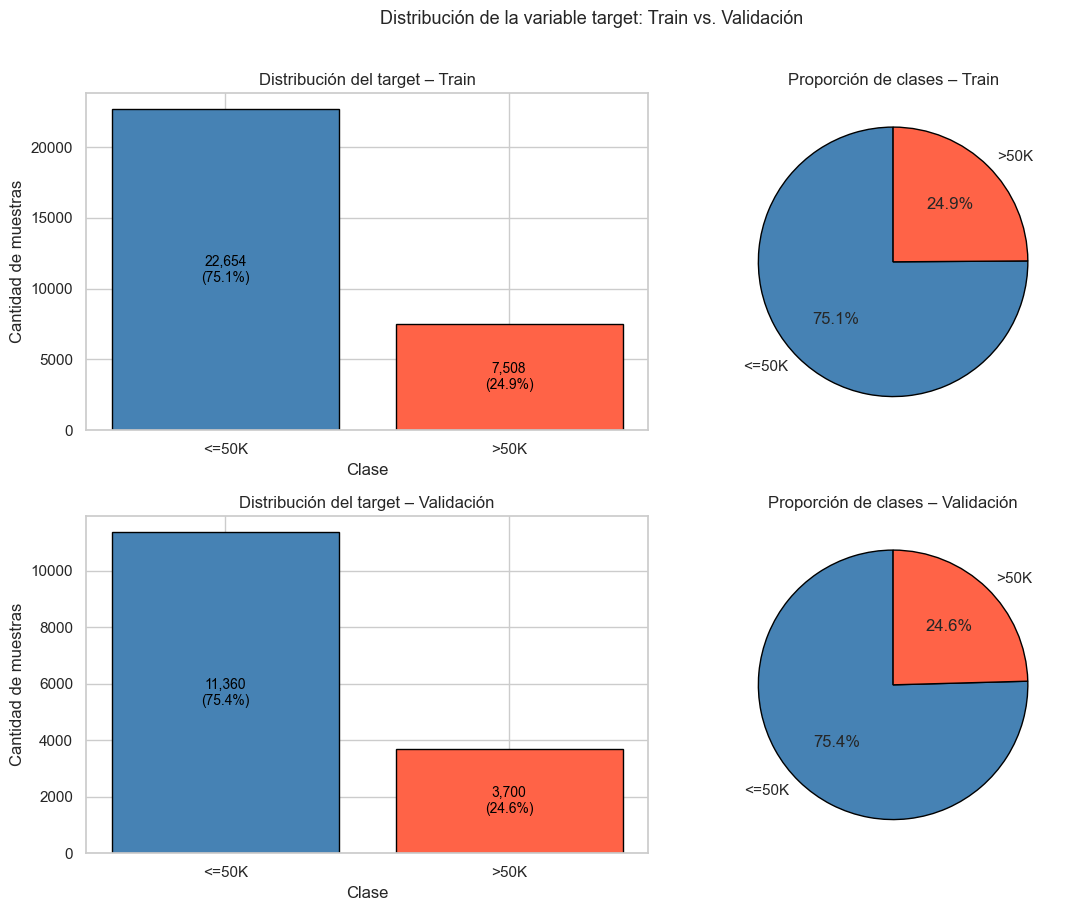

In [9]:
# Veamos el target:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for row, (df, nombre) in enumerate([(df_train, 'Train'), (df_val, 'Validación')]):
    counts = df['income'].value_counts()
    pct    = df['income'].value_counts(normalize=True) * 100

    # Barras
    axes[row, 0].bar(counts.index, counts.values,
                     color=['steelblue', 'tomato'], edgecolor='black')
    for i, (v, p) in enumerate(zip(counts.values, pct.values)):
        axes[row, 0].text(i, v / 2, f'{v:,}\n({p:.1f}%)',
                  ha='center', va='center', fontsize=10, color='black')
    axes[row, 0].set_title(f'Distribución del target – {nombre}', fontsize=12)
    axes[row, 0].set_ylabel('Cantidad de muestras')
    axes[row, 0].set_xlabel('Clase')

    # Pie
    axes[row, 1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                     colors=['steelblue', 'tomato'], startangle=90,
                     wedgeprops={'edgecolor': 'black'})
    axes[row, 1].set_title(f'Proporción de clases – {nombre}', fontsize=12)

plt.suptitle('Distribución de la variable target: Train vs. Validación',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Tiene comportamiento similar en train y test y esta ligeramente desbalanceado (25%)

### Variables numericas

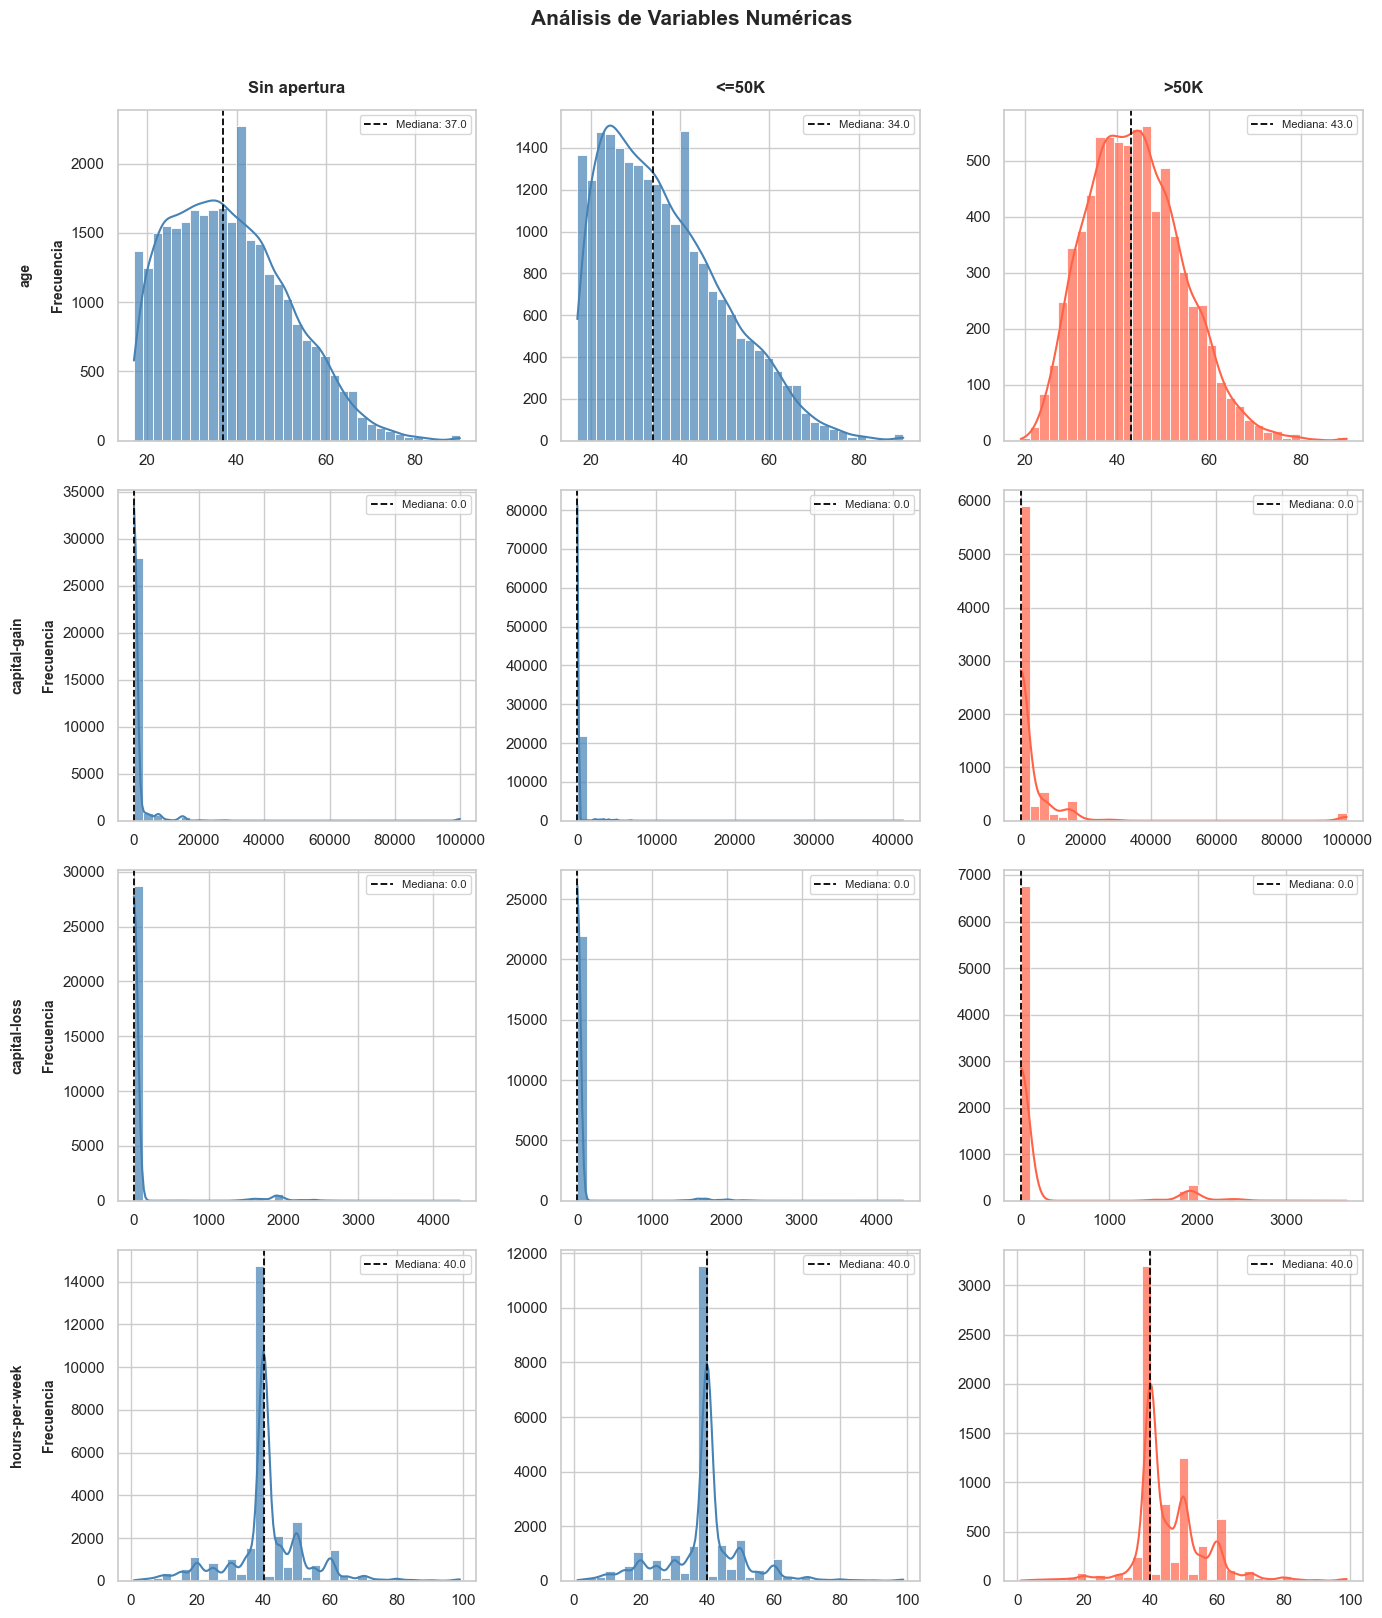

In [10]:
#Veamos las variables numericas:
num_cols = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

col_configs = [
    ('Sin apertura',  df_train,                              'steelblue'),
    ('<=50K',         df_train[df_train['income']=='<=50K'], 'steelblue'),
    ('>50K',          df_train[df_train['income']=='>50K'],  'tomato'),
]

fig, axes = plt.subplots(4, 3, figsize=(14, 16))
fig.suptitle('Análisis de Variables Numéricas', fontsize=15, fontweight='bold', y=1.01)

# Encabezados de columna
for col_idx, (titulo, _, _) in enumerate(col_configs):
    axes[0, col_idx].set_title(titulo, fontsize=12, fontweight='bold', pad=12)

for row_idx, var in enumerate(num_cols):
    for col_idx, (_, data, color) in enumerate(col_configs):
        ax = axes[row_idx, col_idx]
        sns.histplot(data[var], bins=35, kde=True, ax=ax,
                     color=color, edgecolor='white', alpha=0.7)
        ax.axvline(data[var].median(), color='black', linestyle='--',
                   linewidth=1.3, label=f'Mediana: {data[var].median():.1f}')
        ax.legend(fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Frecuencia' if col_idx == 0 else '')

    # Etiqueta de fila
    axes[row_idx, 0].set_ylabel(f'{var}\n\nFrecuencia', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

sns.reset_defaults()

### Analisis de variables numericas

- **`age`**: Las personas con mayores ingresos (>50K) tienden a ser de mayor edad (mediana 43 vs 34), lo que indica que esta variable tiene poder predictivo.
- **`capital-gain`**: Fuerte asimetria (la gran mayoría registra 0). Quienes perciben ganancias de capital suelen tener ingresos mayores, haciéndola potencialmente predictiva.
- **`capital-loss`**: Logica similar a `capital-gain`, con distribución muy asimetrica y predominio de ceros.
- **`hours-per-week`**: Se concentra en torno a 40 horas. Se observa que las personas con >50K tienden a trabajar más horas por semana.

Todas estas variables son continuas y las estandarizaremos con `StandardScaler`. De esta forma garantizamos que las diferencias de escala no afecten el entrenamiento.

### Variables categoricas

In [11]:
# Veamos las variables categoricas:
# Veamos primero la cardinalidad: Mas de 10 categorias los trataremos como cardinalidad alta, menos de 10 como baja

cat_cols = [c for c in df_train.select_dtypes(include='object').columns
            if c != 'income']

resumen_datos = []

for col in cat_cols:
    n_unique = df_train[col].nunique()
    card = "Alta (≥10)" if n_unique >= 10 else "Baja (<10)"
    vals = list(df_train[col].unique())[:4]
    vals_str = str(vals) + ("..." if n_unique > 5 else "")
    
    resumen_datos.append({
        "Variable": col,
        "Unicos": n_unique,
        "Cardinalidad": card,
        "Valores": vals_str
    })

df_resumen_cat = pd.DataFrame(resumen_datos)
df_resumen_cat

,Variable,Unicos,Cardinalidad,Valores
0,workclass,7,Baja (<10),"['State-gov', 'Self-emp-not-inc', 'Private', '..."
1,education,16,Alta (≥10),"['Bachelors', 'HS-grad', '11th', 'Masters']..."
2,marital-status,7,Baja (<10),"['Never-married', 'Married-civ-spouse', 'Divor..."
3,occupation,14,Alta (≥10),"['Adm-clerical', 'Exec-managerial', 'Handlers-..."
4,relationship,6,Baja (<10),"['Not-in-family', 'Husband', 'Wife', 'Own-chil..."
5,race,5,Baja (<10),"['White', 'Black', 'Asian-Pac-Islander', 'Amer..."
6,sex,2,Baja (<10),"['Male', 'Female']"
7,skill-profile,80,Alta (≥10),"['manufacturing_assembly', 'accounting_bookkee..."
8,native-country,41,Alta (≥10),"['United-States', 'Cuba', 'Jamaica', 'India']..."


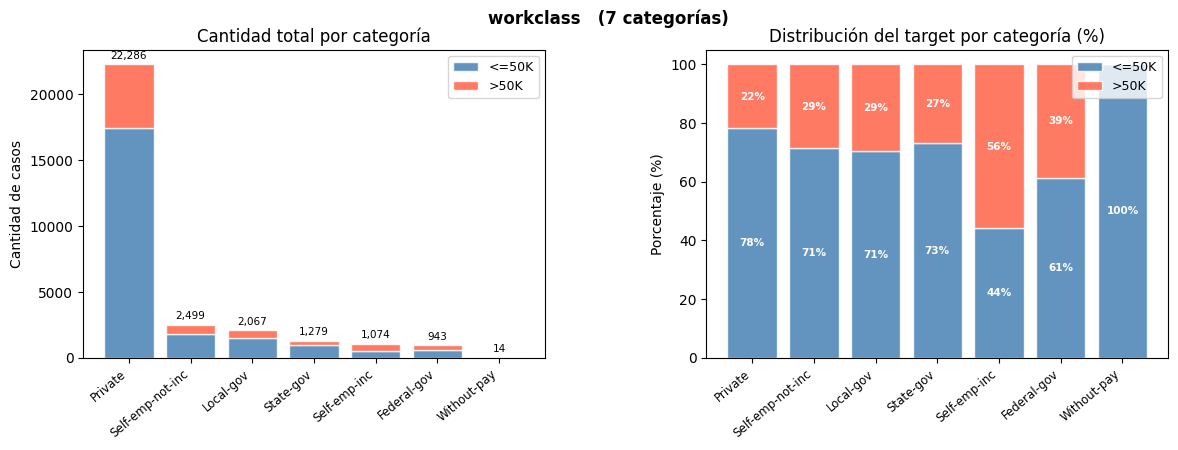

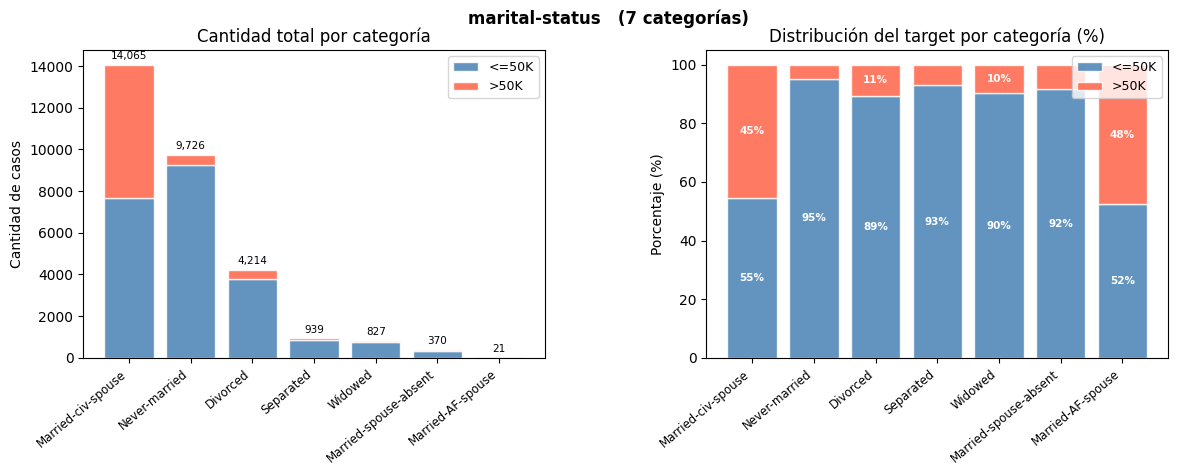

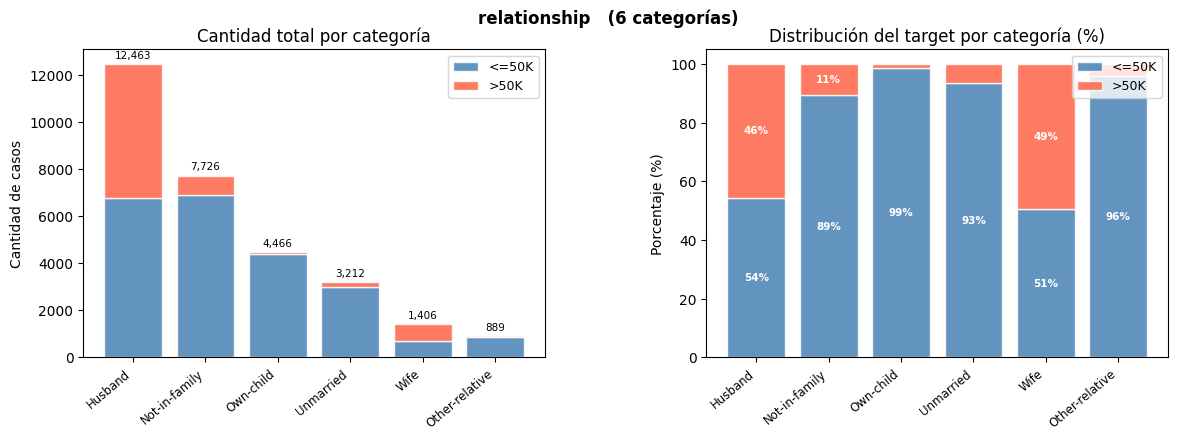

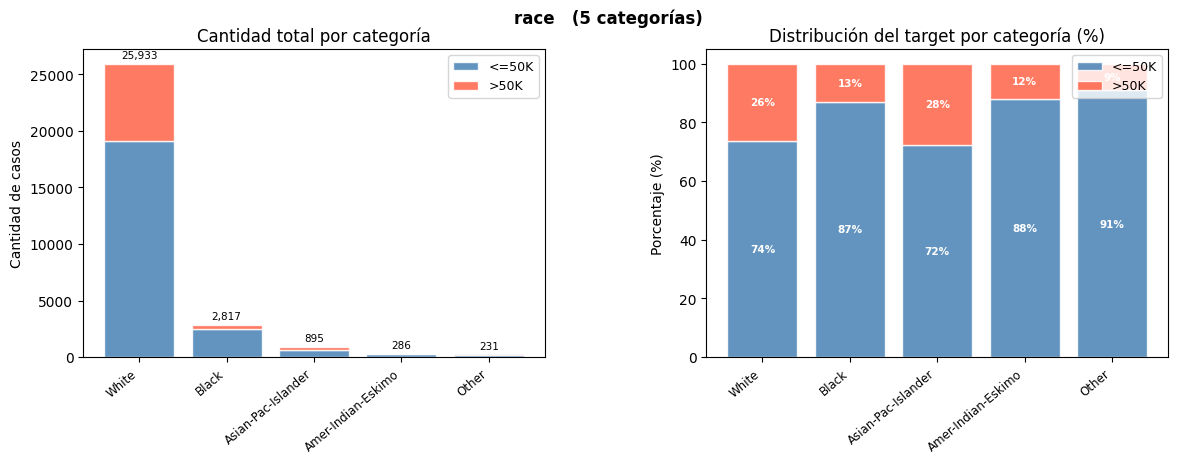

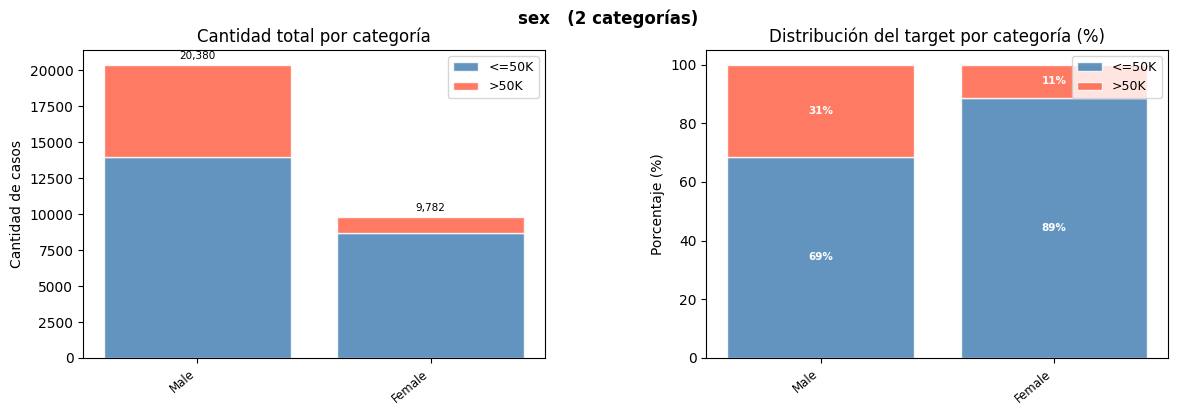

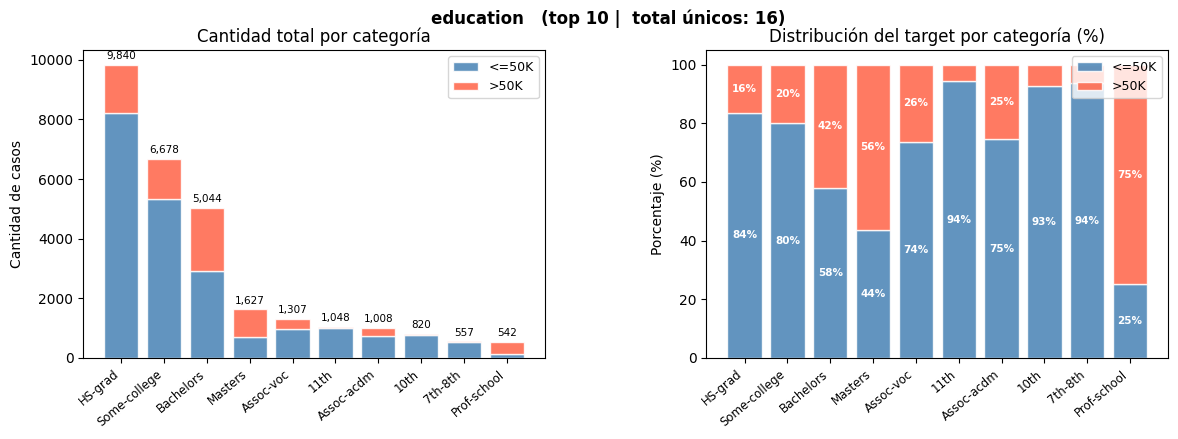

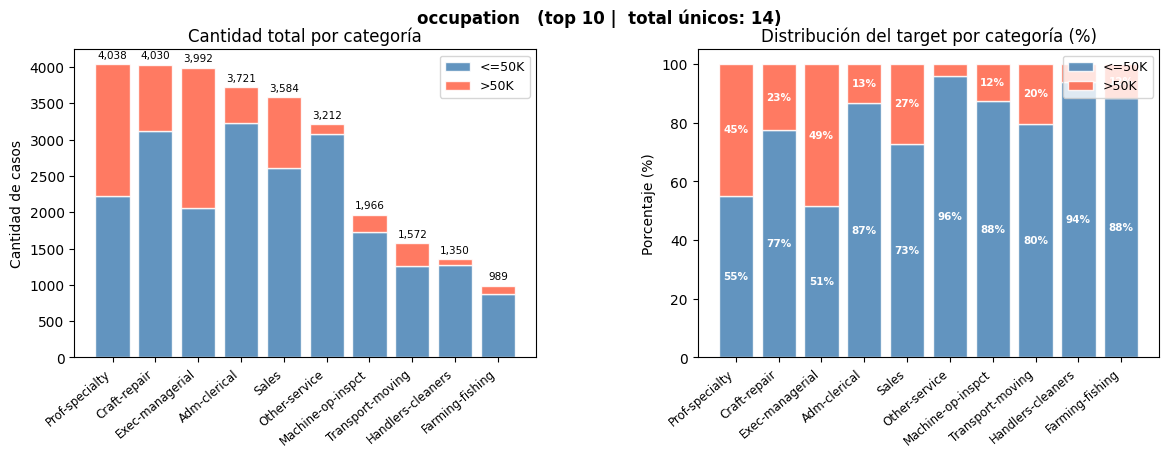

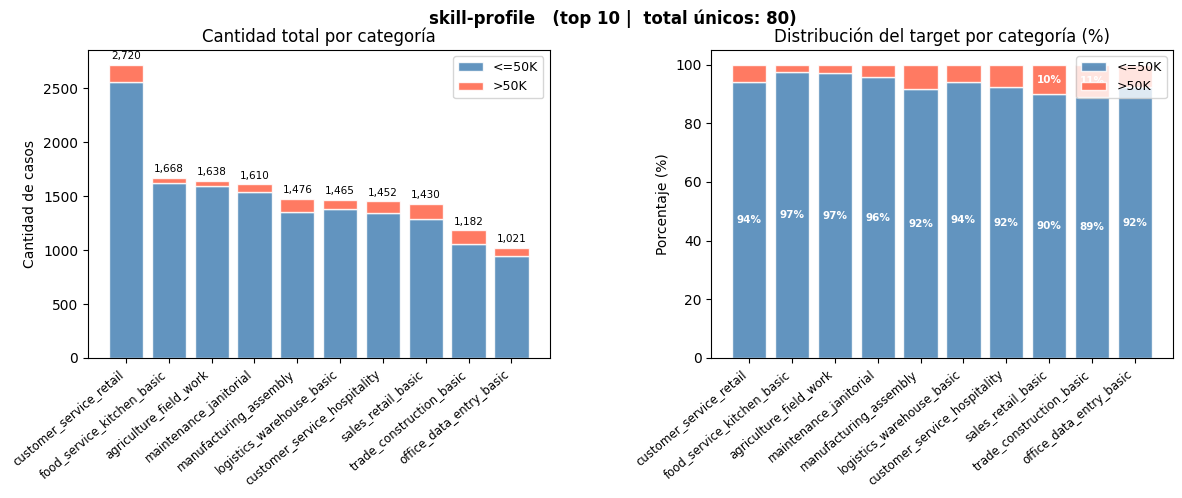

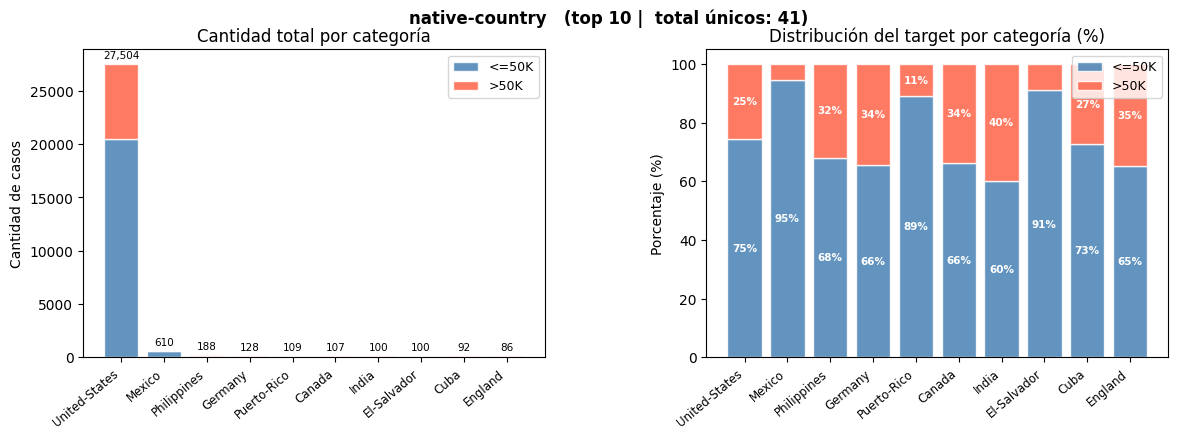

In [12]:
#Grafiquemos las variables:

low_card = ['workclass', 'marital-status', 'relationship', 'race', 'sex']
high_card = ['education', 'occupation', 'skill-profile', 'native-country']

all_cat_cols = low_card + high_card
TOP_N = 10


for var in all_cat_cols:
    n_unique = df_train[var].nunique()
    is_high  = n_unique >= 10

    if is_high:
        top_cats = df_train[var].value_counts().head(TOP_N).index
        data     = df_train[df_train[var].isin(top_cats)]
        subtitle = f'top {TOP_N} |  total únicos: {n_unique}'
    else:
        data     = df_train
        subtitle = f'{n_unique} categorías'

    # Orden fijo: por frecuencia descendente
    order  = data[var].value_counts().index.tolist()
    counts = data[var].value_counts().reindex(order)
    ct = pd.crosstab(data[var], data['income'], normalize='index') * 100
    ct = ct.reindex(order)
    x      = range(len(order))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4),
                                    gridspec_kw={'wspace': 0.35})
    fig.suptitle(f'{var}   ({subtitle})', fontsize=12, fontweight='bold')

    # Grafico Izquierda
    ct_abs = pd.crosstab(data[var], data['income']).reindex(order)
    
    ax1.bar(x, ct_abs['<=50K'], color='steelblue', alpha=0.85,
            label='<=50K', edgecolor='white')
    ax1.bar(x, ct_abs['>50K'],  color='tomato',    alpha=0.85,
            label='>50K', bottom=ct_abs['<=50K'],   edgecolor='white')
    ax1.set_xticks(x)
    ax1.set_xticklabels(order, rotation=40, ha='right', fontsize=8.5)
    ax1.set_ylabel('Cantidad de casos')
    ax1.set_title('Cantidad total por categoría')
    ax1.legend(fontsize=9)
    for i, v in enumerate(counts.values):
        ax1.text(i, v + counts.max() * 0.02, f'{v:,}',
                 ha='center', fontsize=7.5)

    # Grafico Derecha
    ax2.bar(x, ct['<=50K'], color='steelblue', alpha=0.85, label='<=50K', edgecolor='white')
    ax2.bar(x, ct['>50K'],  color='tomato',    alpha=0.85, label='>50K',
            bottom=ct['<=50K'], edgecolor='white')
    ax2.set_xticks(x)
    ax2.set_xticklabels(order, rotation=40, ha='right', fontsize=8.5)
    ax2.set_ylabel('Porcentaje (%)')
    ax2.set_ylim(0, 105)
    ax2.set_title('Distribución del target por categoría (%)')
    #ax2.axhline(50, color='black', linestyle='--', linewidth=0.9, alpha=0.35)
    ax2.legend(fontsize=9, loc='upper right')

    for i, (_, row) in enumerate(ct.iterrows()):
        if row['<=50K'] > 9:
            ax2.text(i, row['<=50K'] / 2, f"{row['<=50K']:.0f}%",
                     ha='center', va='center', fontsize=7.5,
                     color='white', fontweight='bold')
        if row['>50K'] > 9:
            ax2.text(i, row['<=50K'] + row['>50K'] / 2, f"{row['>50K']:.0f}%",
                     ha='center', va='center', fontsize=7.5,
                     color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

sns.reset_defaults()

### Analisis de variables Categoricas
#### Baja cardinalidad: <10 valores unicos

- **`workclass`**: Variable sin orden intrínseco. Presenta 7 valores distintos.
- **`marital-status`**: Variable sin orden claro entre estados civiles.  Presenta 7 valores distintos.
- **`relationship`**: Variable que representa el vínculo con el hogar. Tambien sin orden aparente. Presenta 7 valores distintos.
- **`race`**: Variable sensible, puramente nominal. Presenta 5 valores distintos.
- **`sex`**: Variable binaria. OHE equivale a una codificación 0/1.

Para todas estas variables utilizaremos `One-Hot-Encoding`, ya que es apropiado por la cardinalidad baja y evita imponer jerarquías artificiales.

#### Alta cardinalidad: ≥10 valores unicos

- **`education`**: Aunque tiene un orden natural (Preschool < Doctorate), la relación con el ingreso no es estrictamente lineal. Un embedding aprende representaciones que capturan estas relaciones de forma mas flexible que un ordinal encoding. Presenta 16 valores distintos.
- **`occupation`**: El trabajo tiene patrones complejos respecto del ingreso. El embedding permite al modelo aprender una representación de cada ocupación. Presenta 14 valores distintos.
- **`skill-profile`**: Es la variable con mayor cardinalidad, presentando 80 valores distintos.
- **`native-country`**: Aproximadamente el 90% de los casos tienen el mismo valor ('United-States') Presenta 41 valores distintos.

Para estas variables se utilizan `Embeddings` porque comprimen la alta cardinalidad en un espacio de baja dimensionalidad, evitando las matrices dispersas que genera OHE y permitiendo al modelo aprender las similitudes y diferencias entre categorías.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

torch.manual_seed(14)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")
print(f"PyTorch version: {torch.__version__}")

Usando device: cpu
PyTorch version: 2.11.0+cpu


In [14]:
# En el EDA armamos:
# num_cols: Variables numericas
# low_card: Variables con baja cardinalidad
# high_card: Variables con alta cardinalidad

#num_cols = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
#low_card = ['workclass', 'marital-status', 'relationship', 'race', 'sex']
#high_card = ['education', 'occupation', 'skill-profile', 'native-country']

# Vamos a armar las transformaciones:
# Numericas -> StandardScaler (fit solo en train)
scaler    = StandardScaler()
X_num_train  = scaler.fit_transform(df_train[num_cols])
X_num_val = scaler.transform(df_val[num_cols])

# Baja Cardinalidad -> OHE (fit solo en train)
ohe       = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_low_train  = ohe.fit_transform(df_train[low_card])
X_low_val = ohe.transform(df_val[low_card])

# Alta cardinalidad -> LabelEncoding para capas de Embedding
# Se fitea sobre train+val para evitar categorías desconocidas en validación
# Armamos arreglo de np lleno de ceros para rellenarlo despues
X_high_train  = np.zeros((len(df_train), len(high_card)), dtype=int)
X_high_val = np.zeros((len(df_val),   len(high_card)), dtype=int)
label_encoders = {}
#guardamos las cantidades de clases por variable para embedding
vocab_sizes    = []

for i, col in enumerate(high_card):
    le = LabelEncoder()
    # Fit sobre el conjunto completo para cubrir todas las categorías
    all_vals = pd.concat([df_train[col], df_val[col]], ignore_index=True)
    le.fit(all_vals)
    X_high_train[:, i]  = le.transform(df_train[col])
    X_high_val[:, i] = le.transform(df_val[col])
    label_encoders[col] = le
    vocab_sizes.append(len(le.classes_))
    
# 4. Target -> LabelEncoder
target_le = LabelEncoder()
y_train  = target_le.fit_transform(df_train['income'])
y_val = target_le.transform(df_val['income'])

print("Preprocesamiento completado:")
print(f"   Numéricas         : {X_num_train.shape[1]} features")
print(f"   OHE (baja card.)  : {X_low_train.shape[1]} features")
print(f"   Embedding (alta)  : {len(high_card)} columnas → vocab sizes {dict(zip(high_card, vocab_sizes))}")
print(f"   Clases target     : {dict(enumerate(target_le.classes_))})")

Preprocesamiento completado:
   Numéricas         : 4 features
   OHE (baja card.)  : 27 features
   Embedding (alta)  : 4 columnas → vocab sizes {'education': 16, 'occupation': 14, 'skill-profile': 80, 'native-country': 41}
   Clases target     : {0: '<=50K', 1: '>50K'})


In [15]:
# Armamos el dataloader:
def create_dataloader(X_num, X_low, X_high, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_num,  dtype=torch.float32),
        torch.tensor(X_low,  dtype=torch.float32),
        torch.tensor(X_high, dtype=torch.long),
        torch.tensor(y,      dtype=torch.float32).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader_emb = create_dataloader(X_num_train,  X_low_train,  X_high_train,  y_train)
val_loader_emb   = create_dataloader(X_num_val, X_low_val, X_high_val, y_val, shuffle=False)

print(f"Train batches: {len(train_loader_emb)} | Val batches: {len(val_loader_emb)}")

Train batches: 118 | Val batches: 59


In [16]:
vocab_sizes

[16, 14, 80, 41]

In [17]:
# Creamos la arquitectura

class ModelWithEmbeddings(nn.Module):
    def __init__(self, num_features, low_card_features, vocab_sizes):
        super().__init__()

        # Capas de Embedding: una por cada variable de alta cardinalidad
        # Dimensión: min(50, vocab_size ** 0.5)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=vocab,
                         embedding_dim=max(2, min(50, int(vocab ** 0.5) )))
            for vocab in vocab_sizes
        ])

        total_emb_dim = sum(max(2, min(50, int(v ** 0.5) )) for v in vocab_sizes) 

        # Inicializacion de los embeddings
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, std=0.01)

        # Dimensión total de entrada
        input_dim = num_features + low_card_features + total_emb_dim

        # Capas densas con Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(64, 32),        
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(16, 1),# logit (BCEWithLogitsLoss)
        )
        
        # Inicializamos el bias de salida cerca de la media del target
        nn.init.constant_(self.fc[-1].bias, y_train.mean())

    def forward(self, x_num, x_low, x_high):
        embeds = [emb(x_high[:, i]) for i, emb in enumerate(self.embeddings)]
        x_emb  = torch.cat(embeds, dim=1)
        x      = torch.cat([x_num, x_low, x_emb], dim=1)
        return self.fc(x)


In [18]:
# Instanciamos
model_emb = ModelWithEmbeddings(
    num_features      = X_num_train.shape[1],
    low_card_features = X_low_train.shape[1],
    vocab_sizes       = vocab_sizes
)

total_params_emb = sum(p.numel() for p in model_emb.parameters() if p.requires_grad)
print(model_emb)
print(f"\nTotal parámetros entrenables (Modelo Con Embeddings): {total_params_emb:,}")

# Configuración
criterion   = nn.BCEWithLogitsLoss()
optimizer_emb = optim.Adam(model_emb.parameters(), lr=1e-3, weight_decay=1e-3)
print(f"Dispositivo: {device}")

ModelWithEmbeddings(
  (embeddings): ModuleList(
    (0): Embedding(16, 4)
    (1): Embedding(14, 3)
    (2): Embedding(80, 8)
    (3): Embedding(41, 6)
  )
  (fc): Sequential(
    (0): Linear(in_features=52, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parámetros entrenables (Modelo Con Embeddings): 7,009
Dispositivo: cpu


In [19]:
from copy import deepcopy

def train_model_emb(model, train_loader, val_loader, criterion, optimizer,
                  epochs=100, device='cpu', patience=10, min_delta=1e-4):
    model.to(device)
    history = {k: [] for k in
               ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}

    #  Early stopping
    best_val_loss   = float('inf')
    epochs_no_improv = 0
    best_weights    = deepcopy(model.state_dict())

    for epoch in range(epochs):
        #  Entrenamiento 
        model.train()
        tr_loss, tr_preds, tr_targets = 0.0, [], []
        for x_num, x_low, x_high, y_b in train_loader:
            x_num, x_low, x_high, y_b = (t.to(device)
                for t in [x_num, x_low, x_high, y_b])
            optimizer.zero_grad()
            out  = model(x_num, x_low, x_high)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
            preds = (torch.sigmoid(out).detach().cpu().numpy() >= 0.5).astype(int)
            tr_preds.extend(preds.flatten())
            tr_targets.extend(y_b.cpu().numpy().flatten().astype(int))

        # Validación
        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []
        with torch.no_grad():
            for x_num, x_low, x_high, y_b in val_loader:
                x_num, x_low, x_high, y_b = (t.to(device)
                    for t in [x_num, x_low, x_high, y_b])
                out  = model(x_num, x_low, x_high)
                loss = criterion(out, y_b)
                val_loss += loss.item()
                preds = (torch.sigmoid(out).detach().cpu().numpy() >= 0.5).astype(int)
                val_preds.extend(preds.flatten())
                val_targets.extend(y_b.cpu().numpy().flatten().astype(int))

        # Métricas
        avg_val_loss = val_loss / len(val_loader)
        tr_acc  = accuracy_score(tr_targets,  tr_preds)
        val_acc = accuracy_score(val_targets, val_preds)
        tr_f1   = f1_score(tr_targets,  tr_preds,  average='macro', zero_division=0)
        val_f1  = f1_score(val_targets, val_preds, average='macro', zero_division=0)

        history['train_loss'].append(tr_loss / len(train_loader))
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(tr_acc);  history['val_acc'].append(val_acc)
        history['train_f1'].append(tr_f1);    history['val_f1'].append(val_f1)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:>2}/{epochs} | "
                  f"Loss: {tr_loss/len(train_loader):.4f} / {avg_val_loss:.4f} | "
                  f"Acc: {tr_acc:.4f} / {val_acc:.4f} | "
                  f"F1: {tr_f1:.4f} / {val_f1:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss    = avg_val_loss
            best_weights     = deepcopy(model.state_dict())
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1
            if epochs_no_improv >= patience:
                print(f"\nEarly stopping en epoch {epoch+1} "
                      f"(sin mejora por {patience} epochs consecutivas)")
                break

    # Restaurar los mejores pesos
    model.load_state_dict(best_weights)
    print(f"Mejores pesos restaurados (val_loss: {best_val_loss:.4f})")
    return history, val_preds, val_targets

In [20]:
# Entrenamiento
print("Entrenando Modelo con Embeddings...")
history_emb, preds_emb, targets_emb = train_model_emb(
    model_emb, train_loader_emb, val_loader_emb,
    criterion, optimizer_emb, epochs=1000, device=device
)

Entrenando Modelo con Embeddings...
Epoch  1/1000 | Loss: 0.5172 / 0.2879 | Acc: 0.6614 / 0.8837 | F1: 0.5940 / 0.8375
Epoch  5/1000 | Loss: 0.2714 / 0.2542 | Acc: 0.8901 / 0.8944 | F1: 0.8489 / 0.8541
Epoch 10/1000 | Loss: 0.2646 / 0.2530 | Acc: 0.8935 / 0.8940 | F1: 0.8537 / 0.8543
Epoch 15/1000 | Loss: 0.2648 / 0.2522 | Acc: 0.8935 / 0.8954 | F1: 0.8538 / 0.8556
Epoch 20/1000 | Loss: 0.2637 / 0.2516 | Acc: 0.8930 / 0.8952 | F1: 0.8529 / 0.8561
Epoch 25/1000 | Loss: 0.2622 / 0.2513 | Acc: 0.8931 / 0.8955 | F1: 0.8535 / 0.8554
Epoch 30/1000 | Loss: 0.2597 / 0.2508 | Acc: 0.8944 / 0.8952 | F1: 0.8554 / 0.8558
Epoch 35/1000 | Loss: 0.2602 / 0.2518 | Acc: 0.8960 / 0.8954 | F1: 0.8575 / 0.8522
Epoch 40/1000 | Loss: 0.2590 / 0.2536 | Acc: 0.8949 / 0.8942 | F1: 0.8558 / 0.8492

Early stopping en epoch 41 (sin mejora por 10 epochs consecutivas)
Mejores pesos restaurados (val_loss: 0.2503)


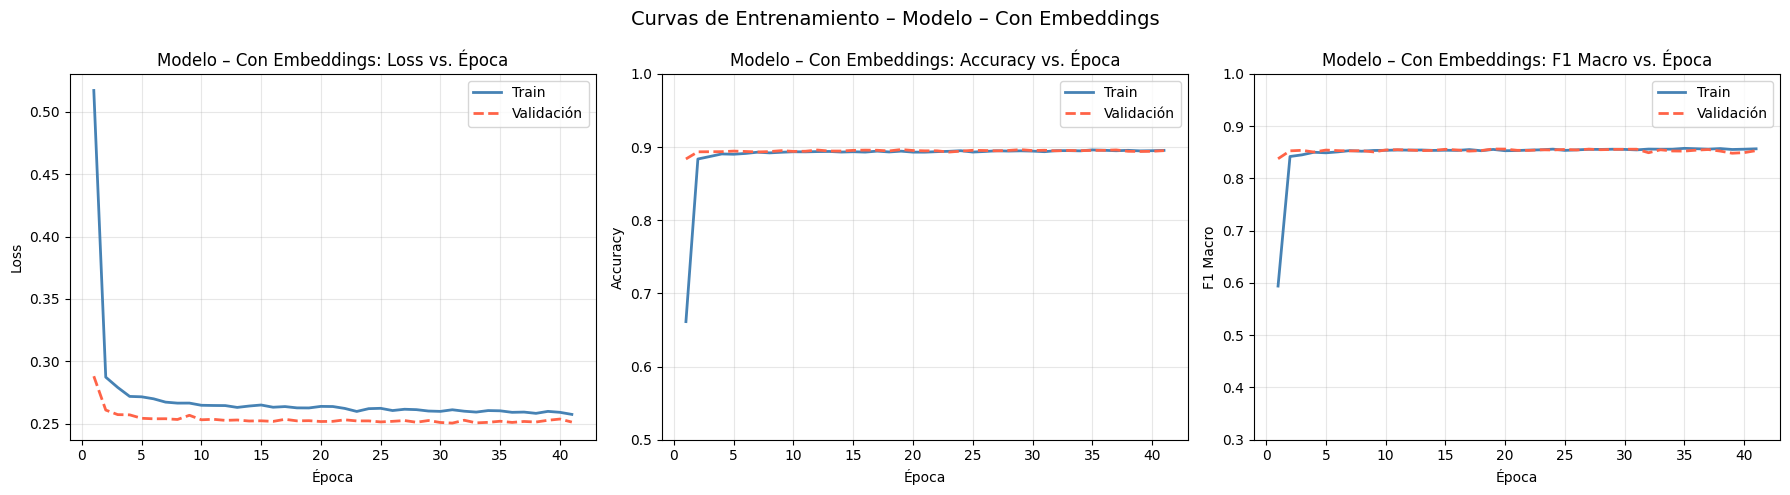

In [21]:
# Metricas:

def plot_training_curves(history, model_name, color_train='steelblue',
                          color_val='tomato'):
    epochs_range = range(1, len(history['train_acc']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(epochs_range, history['train_loss'],
                 color=color_train, label='Train', linewidth=2)
    axes[0].plot(epochs_range, history['val_loss'],
                 color=color_val,   label='Validación', linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name}: Loss vs. Época')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_range, history['train_acc'],
                 color=color_train, label='Train', linewidth=2)
    axes[1].plot(epochs_range, history['val_acc'],
                 color=color_val,   label='Validación', linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name}: Accuracy vs. Época')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.5, 1.0])

    # F1 Macro
    axes[2].plot(epochs_range, history['train_f1'],
                 color=color_train, label='Train', linewidth=2)
    axes[2].plot(epochs_range, history['val_f1'],
                 color=color_val,   label='Validación', linewidth=2, linestyle='--')
    axes[2].set_title(f'{model_name}: F1 Macro vs. Época')
    axes[2].set_xlabel('Época'); axes[2].set_ylabel('F1 Macro')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0.3, 1.0])

    plt.suptitle(f'Curvas de Entrenamiento – {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training_curves(history_emb, 'Modelo – Con Embeddings')

=== Classification Report – Modelo con Embeddings ===
              precision    recall  f1-score   support

       <=50K       0.92      0.95      0.93     11360
        >50K       0.82      0.73      0.77      3700

    accuracy                           0.90     15060
   macro avg       0.87      0.84      0.85     15060
weighted avg       0.89      0.90      0.89     15060



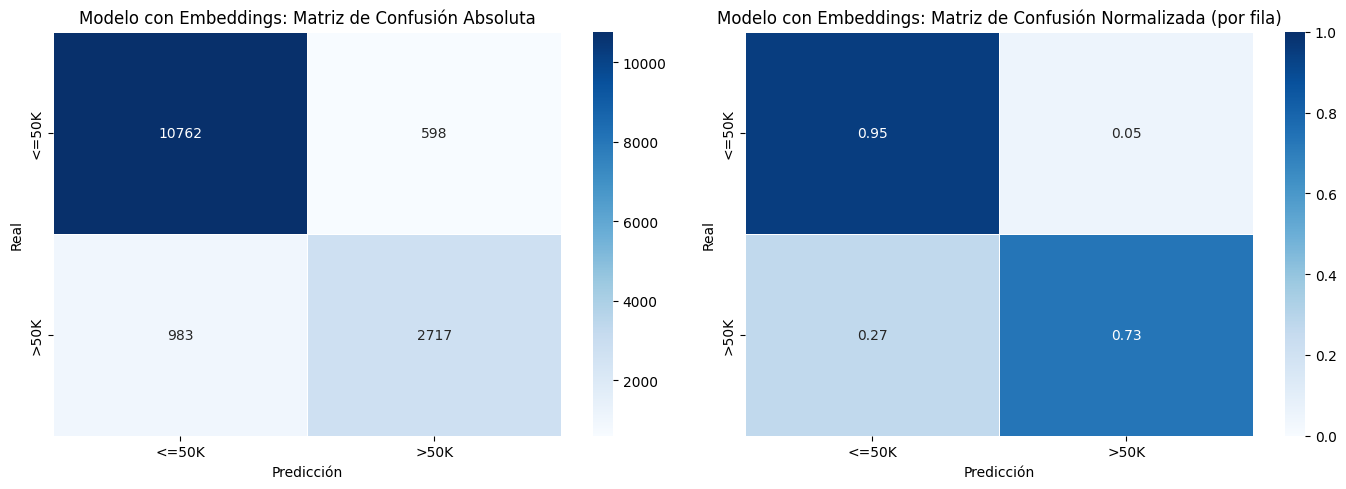

In [22]:
# Metricas;

def plot_confusion_matrices(targets, preds, class_names, model_name,
                             cmap='Blues'):
    cm_abs  = confusion_matrix(targets, preds)
    cm_norm = confusion_matrix(targets, preds, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Absoluta
    sns.heatmap(cm_abs, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=axes[0])
    axes[0].set_title(f'{model_name}: Matriz de Confusión Absoluta')
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

    # Normalizada por fila
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(f'{model_name}: Matriz de Confusión Normalizada (por fila)')
    axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')

    plt.tight_layout()
    plt.show()

class_names = list(target_le.classes_)

print("=== Classification Report – Modelo con Embeddings ===")
print(classification_report(targets_emb, preds_emb, target_names=class_names))

plot_confusion_matrices(targets_emb, preds_emb, class_names,
                        'Modelo con Embeddings', cmap='Blues')

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

In [23]:
# Preprocesamos para sin embeddings

# OHE a TODAS las variables categóricas (baja + alta cardinalidad)
all_cat_cols = low_card + high_card

ohe_all = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Fit solo en train
ohe_all.fit(df_train[all_cat_cols])

X_cat_train_sin_emb  = ohe_all.transform(df_train[all_cat_cols])
X_cat_val_sin_emb = ohe_all.transform(df_val[all_cat_cols])

# Numéricas: mismo scaler del Modelo con embeddings (ya fiteado en train)
X_num_train_sin_emb  = X_num_train.copy()
X_num_val_sin_emb = X_num_val.copy()

# Target: mismo que Modelo con emb
y_train_sin_emb  = y_train.copy()
y_val_sin_emb = y_val.copy()

print("Preprocesamiento Modelo sin embeddings:")
print(f"   Numéricas         : {X_num_train_sin_emb.shape[1]} features")
print(f"   OHE todas categ.  : {X_cat_train_sin_emb.shape[1]} features")
print(f"   Dimensión total   : {X_num_train_sin_emb.shape[1] + X_cat_train_sin_emb.shape[1]} features")
print(f"   (vs Modelo Con Embeddings   : {X_num_train.shape[1] + X_low_train.shape[1]} + embeddings)")

Preprocesamiento Modelo sin embeddings:
   Numéricas         : 4 features
   OHE todas categ.  : 178 features
   Dimensión total   : 182 features
   (vs Modelo Con Embeddings   : 31 + embeddings)


In [24]:
# Armamos el dataloader:
def create_dataloader_sin_emb(X_num, X_cat, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(X_cat, dtype=torch.float32),
        torch.tensor(y,     dtype=torch.float32).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader_sin_emb = create_dataloader_sin_emb(X_num_train_sin_emb,  X_cat_train_sin_emb,  y_train_sin_emb)
val_loader_sin_emb   = create_dataloader_sin_emb(X_num_val_sin_emb, X_cat_val_sin_emb, y_val_sin_emb, shuffle=False)

print(f"Train batches: {len(train_loader_sin_emb)} | Val batches: {len(val_loader_sin_emb)}")

Train batches: 118 | Val batches: 59


In [25]:
# Misma arquitectura de capas
# Sin Dropout, input_dim mayor ->OHE de todas las categorías).

class ModelWithoutEmbeddings(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64), 
            nn.ReLU(),   
            # sin Dropout
            nn.Linear(64, 32),        
            nn.ReLU(),   
            # sin Dropout
            nn.Linear(32, 16),
            nn.ReLU(),   
            # sin Dropout
            nn.Linear(16, 1)
        )
    
        # Inicializamos el bias de salida cerca de la media del target
        nn.init.constant_(self.fc[-1].bias, y_train.mean())

    def forward(self, x_num, x_cat):
        x = torch.cat([x_num, x_cat], dim=1)
        return self.fc(x)

input_dim_sin_emb = X_num_train_sin_emb.shape[1] + X_cat_train_sin_emb.shape[1]
model_sin_emb     = ModelWithoutEmbeddings(input_dim=input_dim_sin_emb)

total_params_sin_emb = sum(p.numel() for p in model_sin_emb.parameters() if p.requires_grad)
print(model_sin_emb)
print(f"\nTotal parámetros entrenables (Modelo Sin Embeddings): {total_params_sin_emb:,}")

ModelWithoutEmbeddings(
  (fc): Sequential(
    (0): Linear(in_features=182, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parámetros entrenables (Modelo Sin Embeddings): 14,337


In [26]:
def train_model_sin_emb(model, train_loader, val_loader, criterion, optimizer,
                       epochs=100, device='cpu', patience=10, min_delta=1e-4):
    model.to(device)
    history = {k: [] for k in
               ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}
    best_val_loss    = float('inf')
    epochs_no_improv = 0
    best_weights     = deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        tr_loss, tr_preds, tr_targets = 0.0, [], []
        for x_num, x_cat, y_b in train_loader:                  # ← 3 tensores
            x_num, x_cat, y_b = (t.to(device) for t in [x_num, x_cat, y_b])
            optimizer.zero_grad()
            out  = model(x_num, x_cat)                          # ← sin x_high
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
            preds = (torch.sigmoid(out).detach().cpu().numpy() >= 0.5).astype(int)
            tr_preds.extend(preds.flatten())
            tr_targets.extend(y_b.cpu().numpy().flatten().astype(int))

        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []
        with torch.no_grad():
            for x_num, x_cat, y_b in val_loader:                # ← 3 tensores
                x_num, x_cat, y_b = (t.to(device) for t in [x_num, x_cat, y_b])
                out  = model(x_num, x_cat)                      # ← sin x_high
                loss = criterion(out, y_b)
                val_loss += loss.item()
                preds = (torch.sigmoid(out).detach().cpu().numpy() >= 0.5).astype(int)
                val_preds.extend(preds.flatten())
                val_targets.extend(y_b.cpu().numpy().flatten().astype(int))

        avg_val_loss = val_loss / len(val_loader)
        tr_acc  = accuracy_score(tr_targets,  tr_preds)
        val_acc = accuracy_score(val_targets, val_preds)
        tr_f1   = f1_score(tr_targets,  tr_preds,  average='macro', zero_division=0)
        val_f1  = f1_score(val_targets, val_preds, average='macro', zero_division=0)

        history['train_loss'].append(tr_loss / len(train_loader))
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(tr_acc);  history['val_acc'].append(val_acc)
        history['train_f1'].append(tr_f1);    history['val_f1'].append(val_f1)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:>2}/{epochs} | "
                  f"Loss: {tr_loss/len(train_loader):.4f} / {avg_val_loss:.4f} | "
                  f"Acc: {tr_acc:.4f} / {val_acc:.4f} | "
                  f"F1: {tr_f1:.4f} / {val_f1:.4f}")

        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss    = avg_val_loss
            best_weights     = deepcopy(model.state_dict())
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1
            if epochs_no_improv >= patience:
                print(f"\nEarly stopping en epoch {epoch+1} "
                      f"(sin mejora por {patience} epochs consecutivas)")
                break

    model.load_state_dict(best_weights)
    print(f"Mejores pesos restaurados (val_loss: {best_val_loss:.4f})")
    return history, val_preds, val_targets

In [27]:
optimizer_sin_emb   = optim.Adam(model_sin_emb.parameters(), lr=1e-3)

# Entrenamiento
print("Entrenando Modelo sin Embeddings...")
history_sin_emb, preds_sin_emb, targets_sin_emb = train_model_sin_emb(
    model_sin_emb, train_loader_sin_emb, val_loader_sin_emb,
    criterion, optimizer_sin_emb, epochs=1000, device=device
)

Entrenando Modelo sin Embeddings...
Epoch  1/1000 | Loss: 0.4435 / 0.2850 | Acc: 0.7500 / 0.8824 | F1: 0.6646 / 0.8381
Epoch  5/1000 | Loss: 0.2462 / 0.2535 | Acc: 0.8951 / 0.8940 | F1: 0.8562 / 0.8498
Epoch 10/1000 | Loss: 0.2348 / 0.2557 | Acc: 0.9003 / 0.8928 | F1: 0.8635 / 0.8484

Early stopping en epoch 14 (sin mejora por 10 epochs consecutivas)
Mejores pesos restaurados (val_loss: 0.2527)


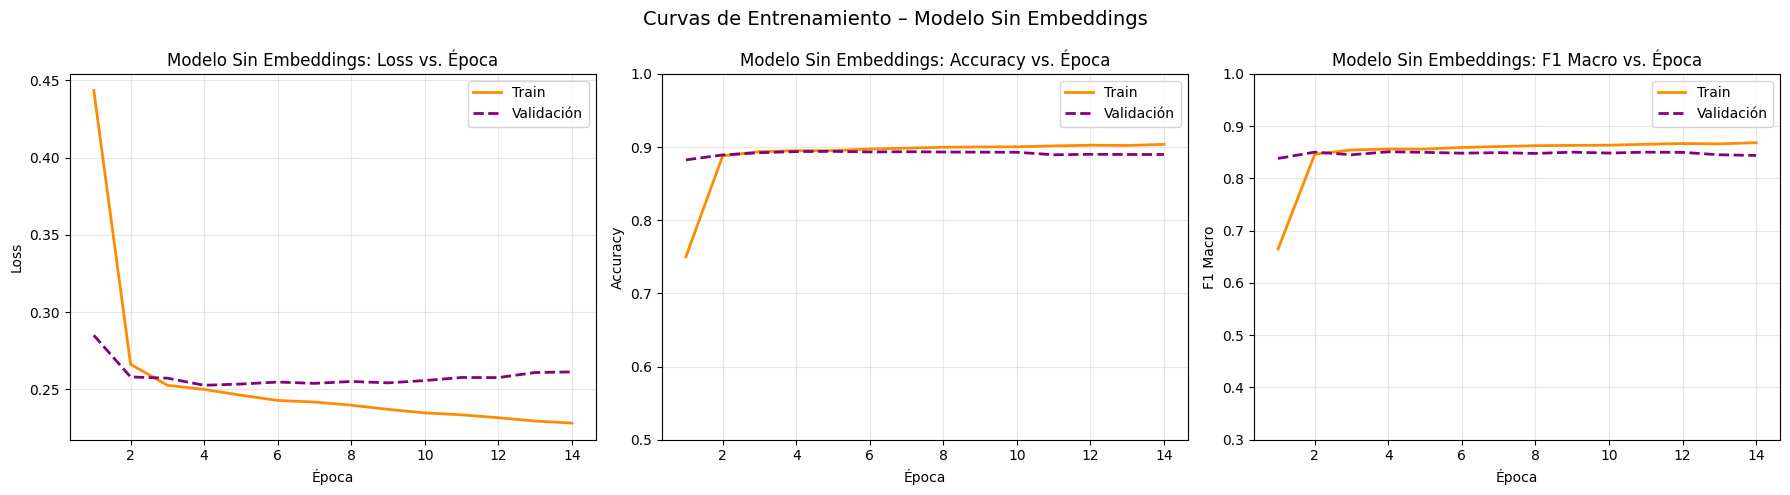

In [28]:
# Metricas
plot_training_curves(history_sin_emb, 'Modelo Sin Embeddings',
                     color_train='darkorange', color_val='purple')

=== Classification Report – Modelo Sin Embeddings ===
              precision    recall  f1-score   support

       <=50K       0.91      0.95      0.93     11360
        >50K       0.82      0.71      0.76      3700

    accuracy                           0.89     15060
   macro avg       0.86      0.83      0.84     15060
weighted avg       0.89      0.89      0.89     15060



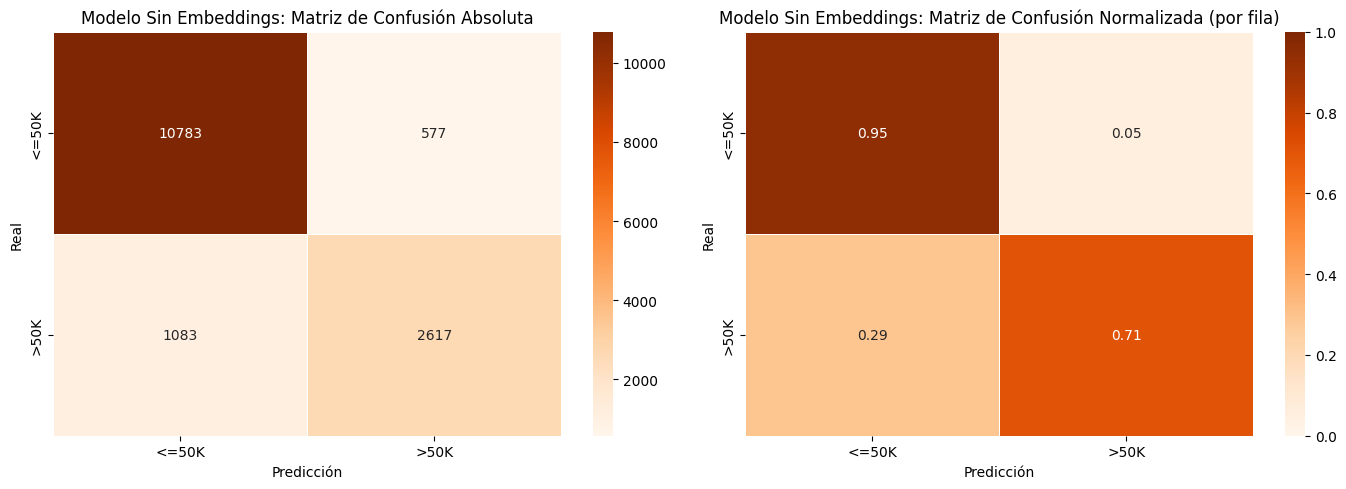

In [29]:
# Metricas
print("=== Classification Report – Modelo Sin Embeddings ===")
print(classification_report(targets_sin_emb, preds_sin_emb, target_names=class_names))

plot_confusion_matrices(targets_sin_emb, preds_sin_emb, class_names,
                        'Modelo Sin Embeddings', cmap='Oranges')


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

,Métrica / Característica,Modelo Con Embeddings,Modelo Sin Embeddings
0,Accuracy (Validación),0.8950,0.8898
1,F1 Macro (Validación),0.8531,0.8439
2,F1 Weighted (Validación),0.8930,0.8869
3,Parámetros entrenables,"7,009","14,337"
4,Dimensión de entrada (efectiva),52 (num + OHE + emb),182 (num + OHE_all)
5,Regularización,Dropout(0.3),Ninguna
6,Codificación alta cardinalidad,Embeddings,One-Hot Encoding


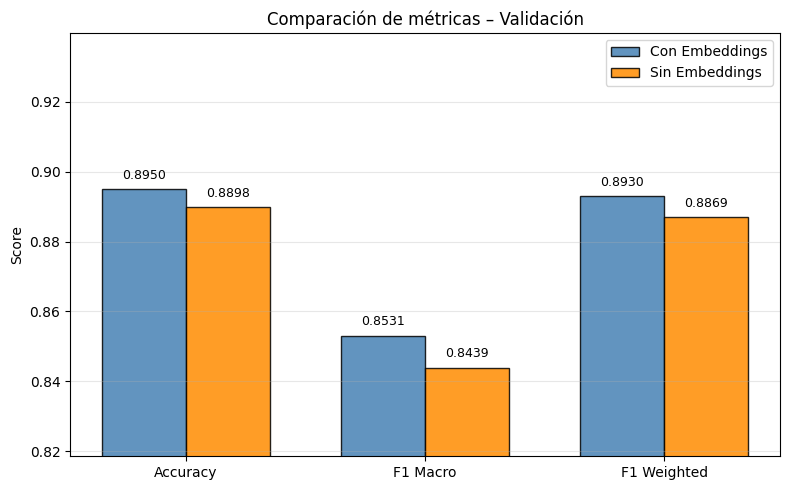

In [30]:
#  Métricas finales 
acc_emb  = accuracy_score(targets_emb, preds_emb)
f1_emb   = f1_score(targets_emb, preds_emb, average='macro',     zero_division=0)
f1w_emb  = f1_score(targets_emb, preds_emb, average='weighted',  zero_division=0)

acc_sin_emb  = accuracy_score(targets_sin_emb, preds_sin_emb)
f1_sin_emb   = f1_score(targets_sin_emb, preds_sin_emb, average='macro',    zero_division=0)
f1w_sin_emb  = f1_score(targets_sin_emb, preds_sin_emb, average='weighted', zero_division=0)

# Parametros
params_emb     = sum(p.numel() for p in model_emb.parameters()     if p.requires_grad)
params_sin_emb = sum(p.numel() for p in model_sin_emb.parameters() if p.requires_grad)

# Dimensión de entrada efectiva
dim_input_emb       = X_num_train.shape[1] + X_low_train.shape[1]
dim_input_emb_total = dim_input_emb + sum(emb.embedding_dim for emb in model_emb.embeddings)
dim_input_sin_emb   = X_num_train_sin_emb.shape[1] + X_cat_train_sin_emb.shape[1]

# Tabla comparativa
tabla = pd.DataFrame({
    'Métrica / Característica': [
        'Accuracy (Validación)',
        'F1 Macro (Validación)',
        'F1 Weighted (Validación)',
        'Parámetros entrenables',
        'Dimensión de entrada (efectiva)',
        'Regularización',
        'Codificación alta cardinalidad',
    ],
    'Modelo Con Embeddings': [
        f'{acc_emb:.4f}',
        f'{f1_emb:.4f}',
        f'{f1w_emb:.4f}',
        f'{params_emb:,}',
        f'{dim_input_emb_total} (num + OHE + emb)',
        'Dropout(0.3)',
        'Embeddings',
    ],
    'Modelo Sin Embeddings': [
        f'{acc_sin_emb:.4f}',
        f'{f1_sin_emb:.4f}',
        f'{f1w_sin_emb:.4f}',
        f'{params_sin_emb:,}',
        f'{dim_input_sin_emb} (num + OHE_all)',
        'Ninguna',
        'One-Hot Encoding',
    ],
})

display(tabla.style.set_caption("Comparación de Modelos"))

# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

metrics      = ['Accuracy', 'F1 Macro', 'F1 Weighted']
vals_emb     = [acc_emb,     f1_emb,     f1w_emb]
vals_sin_emb = [acc_sin_emb, f1_sin_emb, f1w_sin_emb]

x     = np.arange(len(metrics))
width = 0.35

bars_emb     = ax.bar(x - width/2, vals_emb,     width, label='Con Embeddings',
                      color='steelblue',  edgecolor='black', alpha=0.85)
bars_sin_emb = ax.bar(x + width/2, vals_sin_emb, width, label='Sin Embeddings',
                      color='darkorange', edgecolor='black', alpha=0.85)

for bar in bars_emb + bars_sin_emb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

all_vals = vals_emb + vals_sin_emb
ax.set_ylim([min(all_vals) * 0.97, max(all_vals) * 1.05])
ax.set_ylabel('Score')
ax.set_title('Comparación de métricas – Validación')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Observaciones y Conclusiones

#### 1. Desempeño predictivo

El modelo con embeddings obtiene metricas de performance superiores al modelo sin embeddings. Esto se debe a varios motivos:

-Representación de alta cardinalidad: Las variables `education`, `occupation`, `native-country` y `skill-profile` son representadas mediante embeddings entrenables que aprenden relaciones latentes entre categorías. En cambio en el modelo sin embeddings, la codificacion se hace mediante OHE, que trata a las categorias solamente como binarias.

-Regularizacion: El dropout del modelo con embeddings actúa como regularizador, forzando a la red a no depender de ninguna neurona individual. El modelo sin embeddings tiende al overfitting, cuando el espacio de entrada es de alta dimensionalidad. Esto lo podemos observar en el grafico de epoch vs loss para el segundo modelo. Podemos ver como generaliza solo en los primeras epocas, y luego, en validacion, empieza a perder poder predictivo. Esto es un claro ejemplo de overfitting.

#### 2. Dimensionalidad y parámetros

El modelo sin embeddings, al aplicar OHE a todas las variables, tiene una dimensión de entrada mucho mayor. Esto genera un mayor número de parámetros en la primera capa lineal, lo que aumenta el riesgo de overfitting. Los embeddings generan representaciones densas y compactas, con dimensiones mucho menores que el OHE equivalente. <br>
El OHE asume que cada categoría es una entidad independiente y equidistante de todas las demás. Sin embargo, en la realidad existen relaciones entre categorías, por ejemplo, distintos niveles educativos comparten características similares o distintas ocupaciones tienen relaciones salariales similares. Estas similitudes son captadas por los embeddings